# 04 · Feature Selection — Which sensors drive yield failures?

This is the original goal of the SECOM dataset: *rank the signals by their impact on yield*, so process
engineers know which **handful of sensors** to watch and investigate.

Code: [`src/feature_selection.py`](../src/feature_selection.py), tests: [`tests/test_feature_selection.py`](../tests/test_feature_selection.py).
The heavy computation runs as a script (`python -m src.feature_selection`, ~5 min); this notebook reads its outputs.

| Method | View of the data |
|---|---|
| **t-test** (Welch) | univariate, shift in mean |
| **Mutual information** | univariate, any non-linear dependence |
| **L1 logistic regression** | multivariate, sparse and linear |
| **Random forest importance** | multivariate, non-linear, interactions |
| **SHAP** (on a random forest) | multivariate, model-explanation view |

Safeguards:
- Only the **train period** (1175 units, 80 fails) is used. The test period stays untouched for Step 5.
- **Consensus ranking** = mean rank over the 5 methods.
- **Stability selection**: 30 stratified 80% subsamples; how often does a sensor stay in the top 20?
- **Nested cross-validation** for choosing K: the ranking is recomputed *inside* every fold, so the scores
  are not inflated by selection bias (a common mistake with this dataset).

In [1]:
import sys, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))
from src.feature_selection import _rf

FIG_DIR = ROOT / "reports" / "figures"
sns.set_theme(style="whitegrid", context="notebook")
PASS_C, FAIL_C = "#2a9d8f", "#e76f51"

ranking = pd.read_csv(ROOT / "data/processed/feature_ranking.csv", index_col="sensor")
cv = pd.read_csv(ROOT / "data/processed/feature_k_evaluation.csv")
sel = json.load(open(ROOT / "models/selected_features.json"))
train = pd.read_csv(ROOT / "data/processed/train_clean.csv")
methods = ["ttest", "mutual_info", "l1_logistic", "random_forest", "shap"]
print(f"Sensors ranked: {len(ranking)} | chosen K = {sel['k']} ({sel['rule']}, model: {sel['chosen_with']})")

Sensors ranked: 272 | chosen K = 30 (1-SE on nested-CV BER, model: random_forest)


## 1. Do the methods agree?

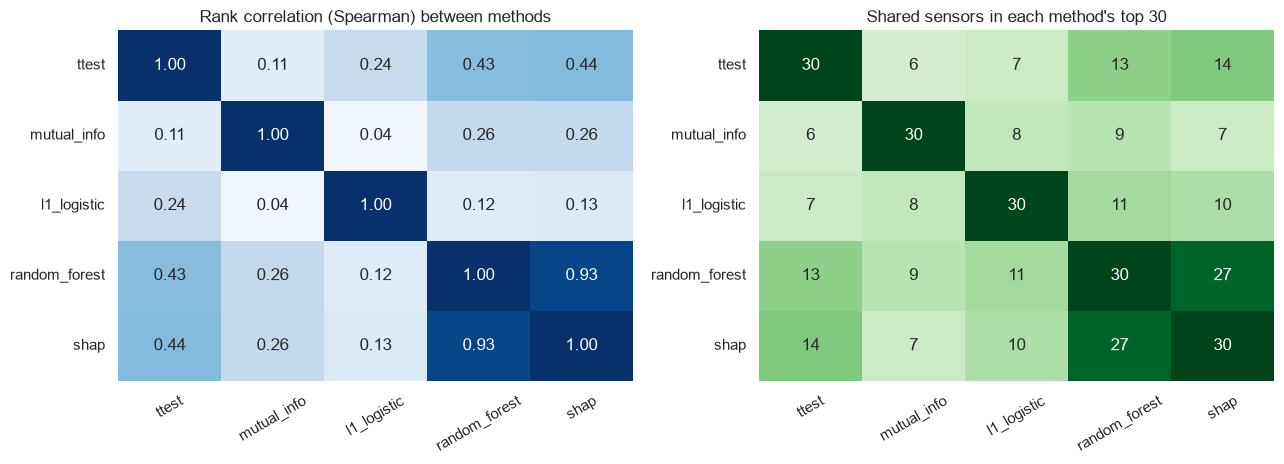

In [2]:
rank_cols = [f"rank_{m}" for m in methods]
spearman = ranking[rank_cols].corr("spearman")
top30 = {m: set(ranking[f"rank_{m}"].nsmallest(30).index) for m in methods}
overlap = pd.DataFrame([[len(top30[a] & top30[b]) for b in methods] for a in methods], index=methods, columns=methods)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
sns.heatmap(spearman.set_axis(methods).set_axis(methods, axis=1), annot=True, fmt=".2f",
            cmap="Blues", vmin=0, vmax=1, ax=axes[0], cbar=False)
axes[0].set_title("Rank correlation (Spearman) between methods")
sns.heatmap(overlap, annot=True, fmt="d", cmap="Greens", vmin=0, vmax=30, ax=axes[1], cbar=False)
axes[1].set_title("Shared sensors in each method's top 30")
for ax in axes:
    ax.tick_params(axis="x", rotation=30)
fig.tight_layout()
fig.savefig(FIG_DIR / "04_method_agreement.png", dpi=150)
plt.show()

**Observation:** the methods **disagree a lot**. Rank correlations are mostly 0.04–0.44, and two methods
typically share only 6–14 of their top-30 sensors. (RF and SHAP agree at 0.93 because SHAP explains that same
random forest.) Any single method would give a fragile, method-specific answer. That is why the
**consensus + stability** approach is used.

## 2. Consensus ranking and stability

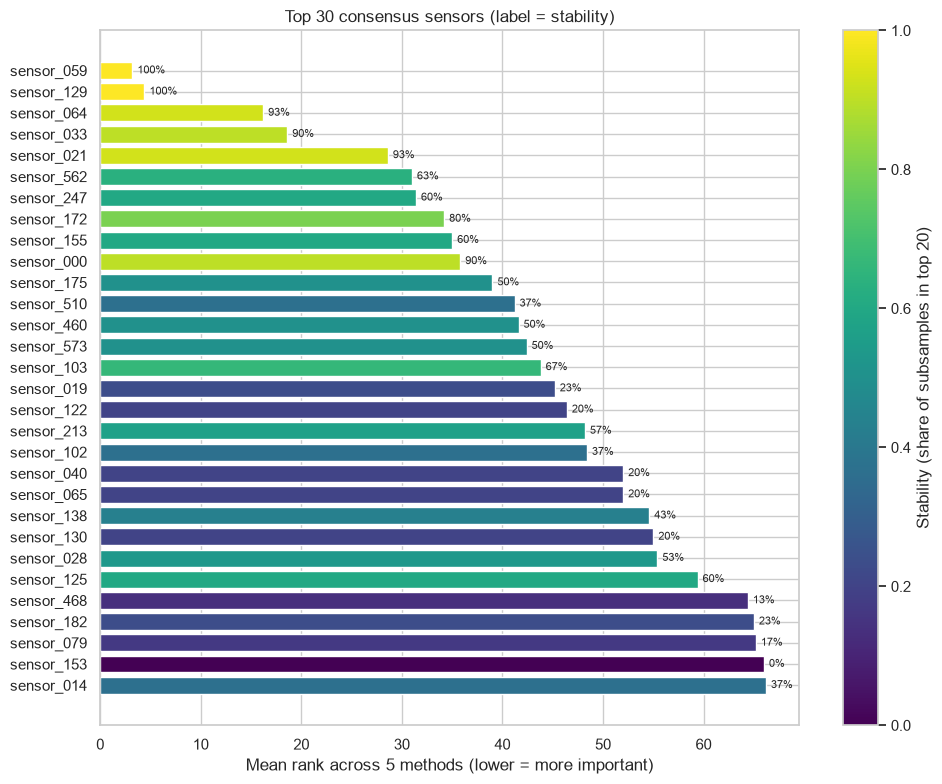

Core sensors (stability >= 80%): 7


,consensus_rank,mean_rank,stability,rank_ttest,rank_mutual_info,rank_l1_logistic,rank_random_forest,rank_shap
sensor,,,,,,,,
sensor_059,1,3.2,1.0,2.0,11.0,1.0,1.0,1.0
sensor_129,2,4.4,1.0,1.0,9.0,2.0,3.0,7.0
sensor_064,3,16.2,0.9,38.0,22.0,4.0,8.0,9.0
sensor_033,4,18.6,0.9,55.0,4.0,23.0,6.0,5.0
sensor_021,5,28.6,0.9,17.0,80.0,10.0,21.0,15.0
sensor_172,8,34.2,0.8,34.0,54.0,7.0,32.0,44.0
sensor_000,10,35.8,0.9,9.0,127.0,20.0,13.0,10.0


In [3]:
top = ranking.head(sel["k"]).copy()
fig, ax = plt.subplots(figsize=(10, 8))
colors = plt.cm.viridis(top["stability"].to_numpy())
ax.barh(top.index[::-1], top["mean_rank"][::-1], color=colors[::-1])
for i, (s, row) in enumerate(top[::-1].iterrows()):
    ax.text(row["mean_rank"] + 0.5, i, f"{row['stability']:.0%}", va="center", fontsize=8)
sm = plt.cm.ScalarMappable(cmap="viridis", norm=plt.Normalize(0, 1))
fig.colorbar(sm, ax=ax, label="Stability (share of subsamples in top 20)")
ax.set(xlabel="Mean rank across 5 methods (lower = more important)",
       title=f"Top {sel['k']} consensus sensors (label = stability)")
fig.tight_layout()
fig.savefig(FIG_DIR / "04_consensus_top_sensors.png", dpi=150)
plt.show()

core = ranking[ranking.stability >= 0.8]
print(f"Core sensors (stability >= 80%): {len(core)}")
core[["consensus_rank", "mean_rank", "stability"] + rank_cols].round(1)

**Observation:** only **7 sensors** are both highly ranked and stable (in the top 20 in ≥ 80% of subsamples):
`sensor_059`, `sensor_129`, `sensor_064`, `sensor_033`, `sensor_021`, `sensor_172`, `sensor_000`.
`sensor_059` and `sensor_129` make the top 20 in **every** subsample. This is the **root-cause shortlist**
to hand to process engineers.

## 3. How many sensors are needed? (nested CV)

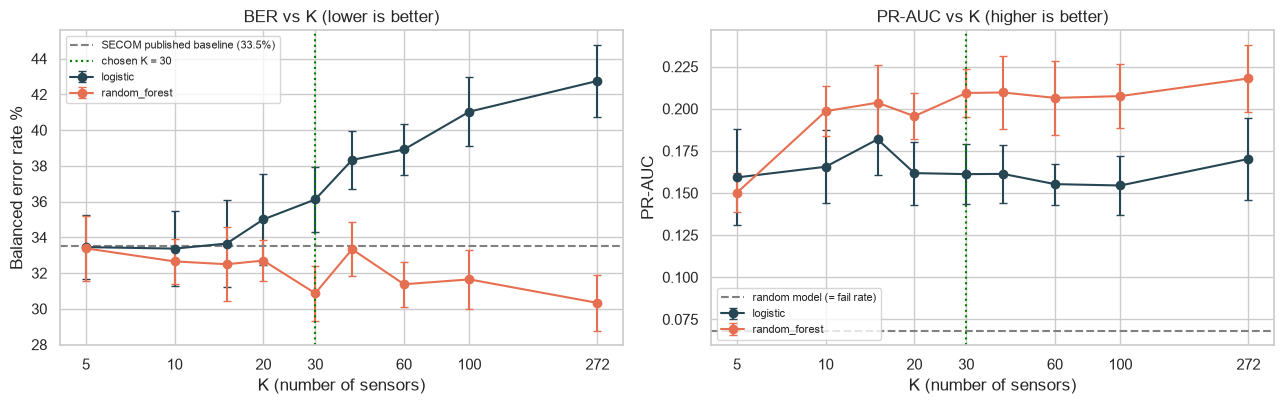

ber                 pr_auc                 recall              
model logistic random_forest logistic random_forest logistic random_forest
k                                                                         
5        0.335         0.334    0.159         0.150    0.644         0.662
10       0.334         0.327    0.166         0.199    0.631         0.644
15       0.337         0.325    0.182         0.204    0.638         0.625
20       0.350         0.327    0.162         0.196    0.662         0.644
30       0.361         0.309    0.161         0.209    0.600         0.681
40       0.383         0.333    0.161         0.210    0.556         0.619
60       0.389         0.314    0.155         0.206    0.569         0.644
100      0.410         0.316    0.154         0.208    0.481         0.662
272      0.427         0.303    0.170         0.218    0.569         0.731

In [4]:
g = cv.groupby(["model", "k"]).agg(ber=("ber", "mean"), ber_se=("ber", lambda s: s.std() / np.sqrt(len(s))),
                                 pr_auc=("pr_auc", "mean"), pr_se=("pr_auc", lambda s: s.std() / np.sqrt(len(s))),
                                 recall=("recall_fail", "mean"), roc_auc=("roc_auc", "mean")).reset_index()
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for name, col in [("logistic", "#264653"), ("random_forest", FAIL_C)]:
    d = g[g.model == name]
    axes[0].errorbar(d.k, d.ber * 100, yerr=d.ber_se * 100, marker="o", capsize=3, color=col, label=name)
    axes[1].errorbar(d.k, d.pr_auc, yerr=d.pr_se, marker="o", capsize=3, color=col, label=name)
axes[0].axhline(33.5, color="grey", ls="--", label="SECOM published baseline (33.5%)")
axes[0].axvline(sel["k"], color="green", ls=":", label=f"chosen K = {sel['k']}")
axes[0].set(xscale="log", xlabel="K (number of sensors)", ylabel="Balanced error rate %",
            title="BER vs K (lower is better)")
axes[1].axhline(train.fail.mean(), color="grey", ls="--", label="random model (= fail rate)")
axes[1].axvline(sel["k"], color="green", ls=":")
axes[1].set(xscale="log", xlabel="K (number of sensors)", ylabel="PR-AUC", title="PR-AUC vs K (higher is better)")
for ax in axes:
    ax.set_xticks([5, 10, 20, 30, 60, 100, 272], [5, 10, 20, 30, 60, 100, 272])
    ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "04_k_selection.png", dpi=150)
plt.show()

g.pivot(index="k", columns="model", values=["ber", "pr_auc", "recall"]).round(3)

**Observations** (5-fold × 2 repeats nested CV on the train period, ±1 standard error):
- **Random forest:** 30 sensors give BER **30.9%**, statistically the same as all 272 sensors (30.3%).
  That is a **9× smaller** sensor set with no measurable loss, so K = 30 is picked with the 1-standard-error rule.
- **Logistic regression** *needs* selection: its BER gets worse from 33.4% (K = 10) to 42.7% (all 272 sensors).
  Too many noisy features hurt a linear model.
- PR-AUC is ≈ 0.21 against 0.068 for a random model, about **3× better than chance**. Useful, but far from
  perfect. SECOM is hard; the published baseline BER is 33.5%, and our nested and therefore honest estimate
  lands at ~31%.

Note: the published baseline used a different protocol (10-fold CV on all data), so the comparison is indicative, not exact.

## 4. Direction of effect — SHAP on the selected sensors

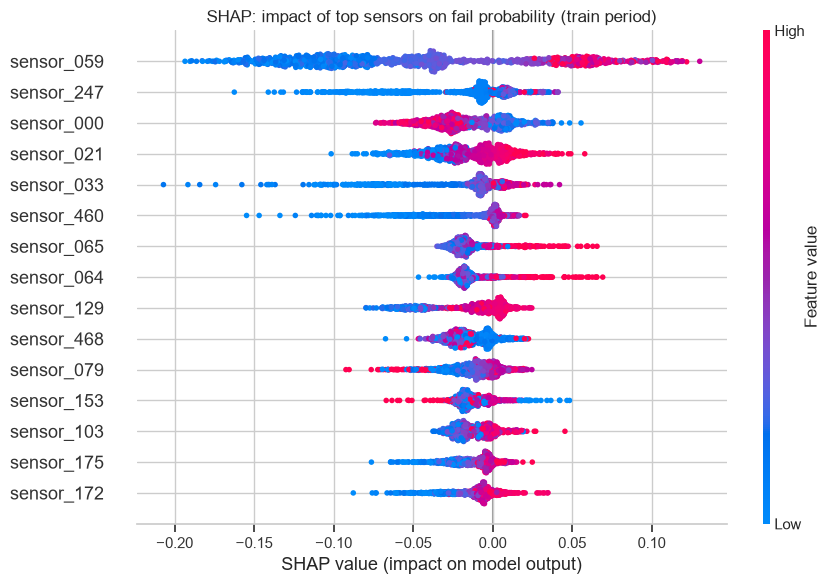

In [5]:
import shap
X = train[sel["features"]]
y = train["fail"]
rf = _rf(n_estimators=300).fit(X, y)
sv = shap.TreeExplainer(rf).shap_values(X, check_additivity=False)
sv = sv[..., 1] if np.ndim(sv) == 3 else sv

plt.figure()
shap.summary_plot(sv, X, max_display=15, show=False, plot_size=(9, 6))
plt.title("SHAP: impact of top sensors on fail probability (train period)")
plt.tight_layout()
plt.savefig(FIG_DIR / "04_shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

How to read it: each dot is one unit. Red means a high sensor value, blue a low one. Dots to the right push the
prediction toward **Fail**. For example, a sensor with red dots on the right means *high readings raise
failure risk*. That gives the engineer a direction to act on, not only a sensor name.

## 5. Root-cause shortlist

In [6]:
raw_train = pd.read_csv(ROOT / "data/processed/secom_merged.csv", parse_dates=["timestamp"]).iloc[:len(train)]
spc_monitored = set(pd.read_csv(ROOT / "data/processed/spc_limits.csv")["sensor"])
short = ranking.head(10)[["consensus_rank", "stability"]].copy()
short["pass_median"] = [raw_train.loc[raw_train.fail == 0, s].median() for s in short.index]
short["fail_median"] = [raw_train.loc[raw_train.fail == 1, s].median() for s in short.index]
short["fail_vs_pass"] = np.where(short.fail_median > short.pass_median, "higher", "lower")
short["mean_abs_shap"] = [np.abs(sv[:, X.columns.get_loc(s)]).mean() for s in short.index]
short["in_SPC_monitor"] = ["yes" if s in spc_monitored else "no" for s in short.index]
short.style.format({"stability": "{:.0%}", "pass_median": "{:.4g}", "fail_median": "{:.4g}", "mean_abs_shap": "{:.4f}"})

,consensus_rank,stability,pass_median,fail_median,fail_vs_pass,mean_abs_shap,in_SPC_monitor
sensor,,,,,,,
sensor_059,1,100%,1.224,9.543,higher,0.0782,yes
sensor_129,2,100%,-0.1419,0,higher,0.0171,yes
sensor_064,3,93%,19.79,20.86,higher,0.0175,no
sensor_033,4,90%,8.769,8.951,higher,0.0210,no
sensor_021,5,93%,-5561,-5456,higher,0.0214,yes
sensor_562,6,63%,264.3,263.5,lower,0.0108,no
sensor_247,7,60%,0.0269,0.0438,higher,0.0251,no
sensor_172,8,80%,0.3265,0.3344,higher,0.0134,no
sensor_155,9,60%,0.32,0.42,higher,0.0100,no


Sensors marked `in_SPC_monitor = no` are **new candidates for the SPC dashboard** from Step 3. Seven of
the ten Step 3 monitored sensors are already inside the selected 30, so the two independent views (univariate
SPC screen vs multivariate consensus) largely agree.

## 6. Takeaways

| # | Finding | Consequence |
|---|---|---|
| 1 | The 5 methods disagree strongly (rank correlation mostly < 0.45) | A single method is fragile, so a consensus of methods is used |
| 2 | 7 core sensors are stable in ≥ 80% of subsamples; `sensor_059` and `sensor_129` in 100% | Root-cause shortlist for engineers |
| 3 | 30 sensors match all 272 in RF performance (BER 30.9% vs 30.3%) | 9× smaller, easier to monitor and explain |
| 4 | Logistic regression degrades badly with all sensors (33% → 43% BER) | Feature selection is essential for linear models |
| 5 | Honest nested-CV BER ≈ 31% vs published baseline 33.5% | Realistic starting point for Step 5 |

**Outputs:** `data/processed/feature_ranking.csv` (all 272 sensors: scores, ranks, stability, selected flag),
`data/processed/feature_k_evaluation.csv` (every fold/K/model result), `models/selected_features.json` (the 30 sensors used next).